# Занятие 12. Практика: анализ формы данных и плотности — АВТОРСКОЕ РЕШЕНИЕ

На прошлом занятии разобрали теорию: меры центра и разброса, **форму распределения**
(асимметрия `.skew()`, эксцесс `.kurt()`), **гистограммы** и **KDE**, виды распределений
(нормальное, логнормальное, экспоненциальное), генеральную совокупность и выборку.

Сегодня применяем это на практике: анализируем **форму** реальных признаков через
`histplot` и `kdeplot`, сравниваем распределения групп и — главное — учимся
**нормализовать скошенные данные нелинейными преобразованиями** (логарифм, корень).

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid')

---
## Повторение инструментов

Вспомним инструменты на **простых сгенерированных примерах**. Реальные данные
(`salaries.csv`) вы будете анализировать сами — в заданиях ниже.

In [40]:
rng = np.random.default_rng(0)
demo = pd.Series(rng.lognormal(mean=0, sigma=0.7, size=800))   # заведомо скошенный пример
demo.head()

0    1.092000
1    0.911673
2    1.565642
3    1.076193
4    0.687311
dtype: float64

### Гистограмма, KDE и форма через `.skew()`

`histplot(kde=True)` показывает форму распределения, а `.skew()` описывает её числом:
0 — симметрично, больше нуля — хвост справа (скос вправо), меньше нуля — хвост слева.

skew: 2.26


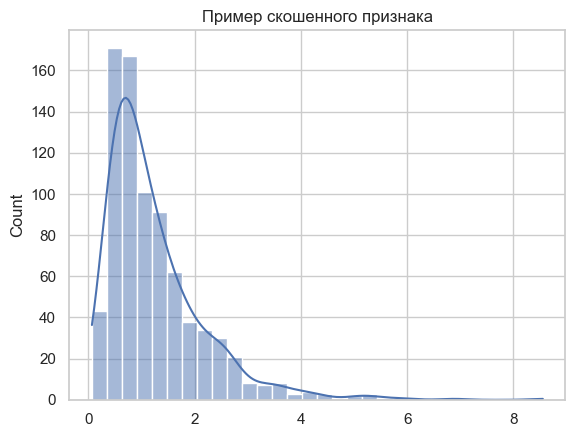

In [41]:
sns.histplot(demo, bins=30, kde=True)
plt.title('Пример скошенного признака')
print('skew:', round(demo.skew(), 2));

**Вывод:** у примера асимметрия заметно больше нуля — распределение скошено вправо (длинный правый хвост).

### Нормализация логарифмом

Логарифм «сжимает» правый хвост и приближает скошенное распределение к нормальному.
Сравниваем асимметрию до и после — она должна упасть ближе к нулю:

In [42]:
print('до логарифма:', round(demo.skew(), 2))
print('после np.log:', round(np.log(demo).skew(), 2));

до логарифма: 2.26
после np.log: -0.1


**Вывод:** после `np.log` асимметрия близка к 0 — форма стала почти симметричной. (Если в данных есть нули, берут `np.log1p`.)

### Как читать величину `skew`

Асимметрия — это и **сила**, и **сторона** скоса. Ориентир по модулю:

| `skew` | Что значит | Что делать |
|---|---|---|
| \|skew\| < 0.5 | почти симметрично | преобразование не нужно |
| 0.5 – 1 | умеренный скос | по ситуации |
| \|skew\| > 1 | сильный скос | стоит логарифмировать (если вправо) |

Знак: положительный — хвост справа, отрицательный — слева.

### `kdeplot` с разбивкой по группам

`kdeplot(hue=...)` рисует **плотности групп** на одном графике. Площадь под каждой кривой
равна 1, поэтому группы даже разного размера сравнимы по форме. Пример с двумя группами:

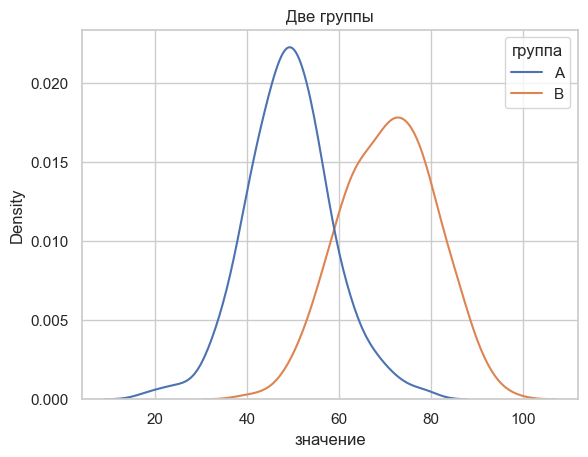

In [43]:
demo_groups = pd.DataFrame({
    'значение': np.concatenate([rng.normal(50, 10, 300), rng.normal(70, 10, 300)]),
    'группа': ['A'] * 300 + ['B'] * 300,
})
sns.kdeplot(data=demo_groups, x='значение', hue='группа')
plt.title('Две группы');

**Вывод:** две кривые — два пика: у группы B центр правее. Так `kdeplot` сравнивает распределения подгрупп на одном графике.

### Как вернуться из логарифма

Логарифм обратим: обратно возвращает `np.exp`. Удобно, что **медиана** сохраняется —
`exp` от медианы логарифмов даёт исходную медиану:

In [44]:
log_median = np.log(demo).median()
print('обратно (np.exp):', round(np.exp(log_median), 2))
print('медиана примера :', round(demo.median(), 2));

обратно (np.exp): 0.97
медиана примера : 0.97


**Вывод:** `np.exp` вернул исходную медиану — можно работать в логарифмах, а результат переводить обратно для интерпретации.

---
## Практика

Ниже — **10 заданий** (максимум **30 баллов**). Это **исследовательские** задачи:
- **постройте график(и)** в ячейке `# Ваш код` — код обязателен;
- заполните пункт **Вывод:** — что видно на графике и **какой вывод** из этого следует.

Оцениваются и построение, и содержательность вывода. Часть заданий — про нормализацию
скошенных данных, часть — про сравнение распределений разных групп.

### Датасет — `salaries.csv`

**1200 сотрудников** IT-компании, **12 колонок**:

| Столбец | Что это |
|---|---|
| `employee_id` | id сотрудника |
| `department` | отдел (Инженерия, Продажи, Маркетинг, HR, Финансы, Поддержка) |
| `grade` | грейд: Junior / Middle / Senior / Lead |
| `education` | образование: Бакалавр / Магистр / PhD |
| `city` | город |
| `gender` | пол |
| `remote` | формат работы: Да (удалёнка) / Нет (офис) |
| `age` | возраст |
| `experience` | опыт, лет |
| `performance` | оценка эффективности 1–5 |
| `salary` | зарплата, руб. |
| `bonus` | годовой бонус, руб. |

Загружаем датасет:

In [45]:
df = pd.read_csv('data/salaries.csv', sep=';')
print('salaries.csv:', df.shape)
df.head()

salaries.csv: (1200, 12)


,employee_id,department,grade,education,city,gender,remote,age,experience,performance,salary,bonus
0,1000,Маркетинг,Junior,Бакалавр,Москва,Ж,Нет,26,0,4,77221,11632
1,1001,Инженерия,Middle,Бакалавр,Москва,Ж,Да,33,3,5,151093,7784
2,1002,Инженерия,Senior,Магистр,Москва,М,Нет,36,7,5,326473,9410
3,1003,Инженерия,Junior,PhD,Москва,М,Да,23,0,5,124353,8475
4,1004,Финансы,Middle,Бакалавр,Москва,Ж,Нет,34,5,4,146694,32831


### <font color='DarkOrange'>Задание 1 [2 балла]</font>

Постройте **гистограмму с кривой плотности** (`histplot` с `kde=True`) для зарплаты (`salary`) и посчитайте её асимметрию (`.skew()`). Опишите форму распределения словами.

skew: 1.48


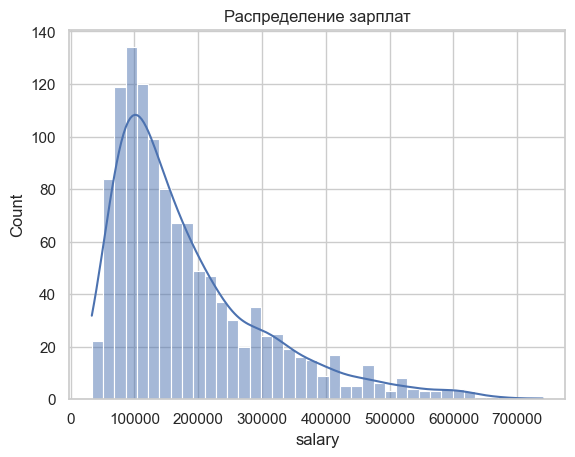

In [46]:
sns.histplot(data=df, x='salary', bins=40, kde=True)
plt.title('Распределение зарплат')
print('skew:', round(df['salary'].skew(), 2));
# Ожидаемый результат: сильный скос вправо, skew ~ 1.48 (длинный хвост высоких зарплат)

**Вывод:** Распределение зарплат сильно скошено вправо (skew ≈ 1.5): большинство получает умеренно, а немногочисленные высокие зарплаты тянут длинный правый хвост.

### <font color='DarkOrange'>Задание 2 [3 балла]</font>

**Логарифмируйте** зарплату: создайте столбец `log_salary = np.log(df['salary'])`, постройте его гистограмму с KDE и сравните асимметрию **до и после** логарифмирования. Что стало с формой?

skew salary: 1.48
skew log: 0.23


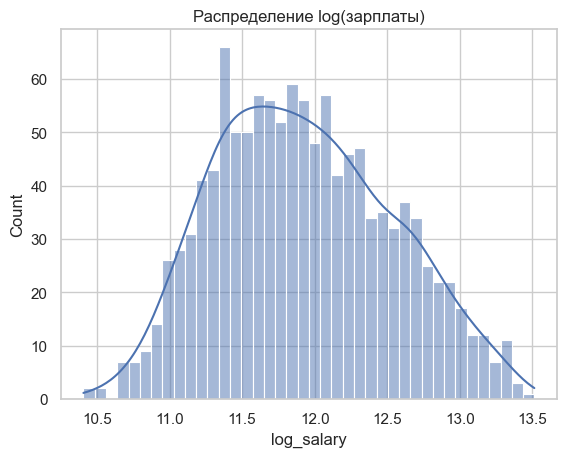

In [47]:
df['log_salary'] = np.log(df['salary'])
sns.histplot(data=df, x='log_salary', bins=40, kde=True)
plt.title('Распределение log(зарплаты)')
print('skew salary:', round(df['salary'].skew(), 2))
print('skew log:', round(df['log_salary'].skew(), 2));
# Ожидаемый результат: skew падает с ~1.48 до ~0.23 — форма стала почти симметричной (колокол)

**Вывод:** Логарифм превратил скошенное распределение в почти симметричное: асимметрия упала с ~1.48 до ~0.23, гистограмма стала похожа на «колокол». Так скошенные признаки приводят к нормальному виду.

### <font color='DarkOrange'>Задание 3 [3 балла]</font>

Сравните два преобразования скошенной зарплаты — **корень** (`np.sqrt`) и **логарифм** (`np.log`). Постройте оба распределения и посчитайте асимметрию каждого. Какое преобразование лучше приближает к нормальному виду?

skew sqrt: 0.84
skew log: 0.23


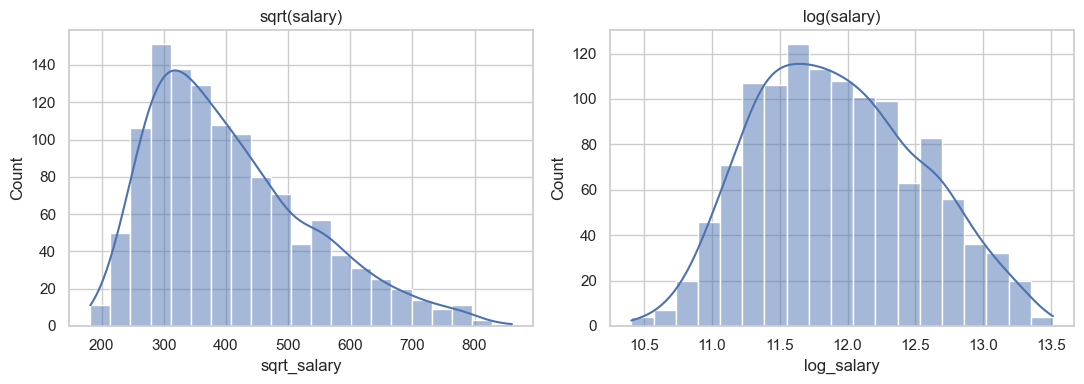

In [48]:
df['sqrt_salary'] = np.sqrt(df['salary'])
df['log_salary'] = np.log(df['salary'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=df, x='sqrt_salary', kde=True, ax=axes[0]); axes[0].set_title('sqrt(salary)')
sns.histplot(data=df, x='log_salary', kde=True, ax=axes[1]); axes[1].set_title('log(salary)')
plt.tight_layout()
print('skew sqrt:', round(df['sqrt_salary'].skew(), 2))
print('skew log:', round(df['log_salary'].skew(), 2));
# Ожидаемый результат: sqrt ~0.84 (частично), log ~0.23 (почти симметрично) -> лучше log

**Вывод:** Корень уменьшил скос лишь частично (skew ~0.84), а логарифм почти убрал его (skew ~0.23). Для сильно скошенных вправо данных логарифм нормализует лучше корня.

### <font color='DarkOrange'>Задание 4 [3 балла]</font>

Постройте **графики плотности** (`kdeplot`) зарплаты **по грейдам** (`hue='grade'`) и посчитайте медианную зарплату каждого грейда. Как отличаются распределения грейдов по типичному уровню и разбросу?

grade
Junior     87064.0
Lead      411423.0
Middle    156055.0
Senior    265771.0
Name: salary, dtype: float64


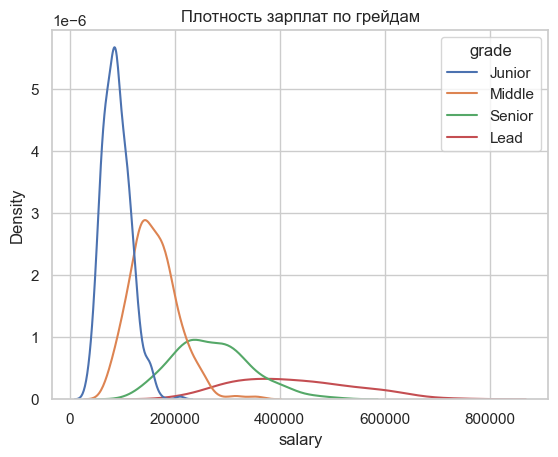

In [49]:
sns.kdeplot(data=df, x='salary', hue='grade')
plt.title('Плотность зарплат по грейдам')
print(df.groupby('grade')['salary'].median().round());
# Ожидаемый результат: медианы Junior ~87k, Middle ~156k, Senior ~266k, Lead ~411k;
# с ростом грейда пик смещается вправо и распределение становится шире

**Вывод:** С ростом грейда медианная зарплата растёт (Junior ~87k → Lead ~411k), а распределение смещается вправо и расширяется: у Lead и разброс, и уровень заметно выше — грейд почти полностью определяет зарплату.

### <font color='DarkOrange'>Задание 5 [3 балла]</font>

Исследуйте форму признака **`experience`** (опыт): постройте гистограмму с KDE и посчитайте асимметрию. Это распределение скошенное или симметричное? В какую сторону?

skew experience: 0.82


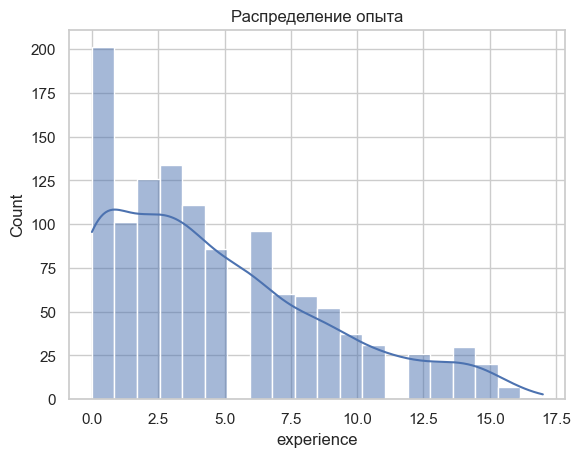

In [50]:
sns.histplot(data=df, x='experience', bins=20, kde=True)
plt.title('Распределение опыта')
print('skew experience:', round(df['experience'].skew(), 2));
# Ожидаемый результат: умеренный скос вправо, skew ~0.82 (много новичков, длинный хвост опытных)

**Вывод:** Опыт скошен вправо, но слабее зарплаты (skew ≈ 0.8): преобладают сотрудники с небольшим стажем, а очень опытных мало — они образуют правый хвост.

### <font color='DarkOrange'>Задание 6 [4 балла]</font>

Составьте **«карту скошенности»** данных: посчитайте асимметрию (`.skew()`) для всех числовых признаков — `salary`, `bonus`, `age`, `experience`, `performance` — и отсортируйте (можно вывести таблицей или горизонтальными столбцами). Какие признаки сильно скошены **вправо** (кандидаты на логарифм), какие почти симметричны, а какой скошен **влево**?

bonus          2.06
salary         1.48
experience     0.82
age            0.53
performance   -0.63
dtype: float64


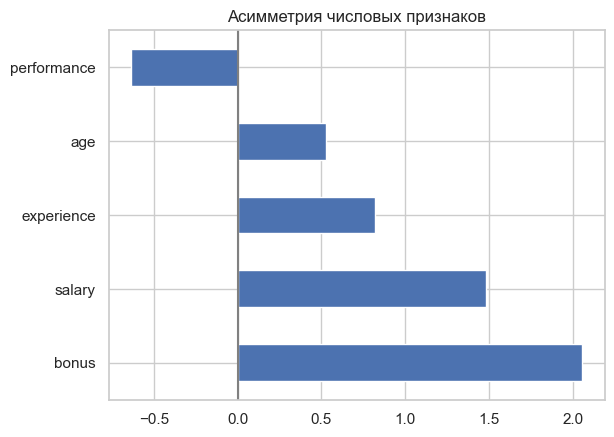

In [51]:
cols = ['salary', 'bonus', 'age', 'experience', 'performance']
skews = df[cols].skew().sort_values(ascending=False)
print(skews.round(2))

skews.plot(kind='barh', title='Асимметрия числовых признаков')
plt.axvline(0, color='gray');
# Ожидаемый результат: bonus 2.06 и salary 1.48 — сильный скос вправо (логарифм);
# experience 0.82, age 0.53 — умеренный/слабый; performance -0.63 — скос ВЛЕВО

**Вывод:** Сильнее всех скошены вправо bonus (~2.06) и salary (~1.48) — их стоит логарифмировать. Опыт и возраст скошены умеренно, а performance скошен **влево** (~−0.63): большинство оценок высокие (4–5), а низкие образуют левый хвост. Знак и величина skew сразу подсказывают, что и как преобразовывать.

### <font color='DarkOrange'>Задание 7 [3 балла]</font>

Сравните распределение зарплат для **удалёнщиков и офисных** (`kdeplot` с `hue='remote'`) и посчитайте медиану каждой группы. Есть ли между ними реальная разница?

remote
Да     143415.0
Нет    145530.0
Name: salary, dtype: float64


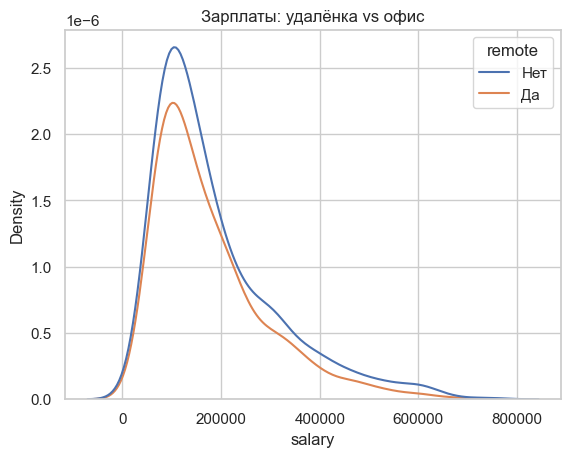

In [52]:
sns.kdeplot(data=df, x='salary', hue='remote')
plt.title('Зарплаты: удалёнка vs офис')
print(df.groupby('remote')['salary'].median().round());
# Ожидаемый результат: медианы ~143k и ~145k — практически совпадают, кривые почти наложены;
# формат работы на зарплату здесь не влияет

**Вывод:** Кривые плотности почти совпадают, медианы близки (~143k и ~145k) — заметной разницы нет. Важный вывод: не всякий срез данных даёт различие; формат работы (удалёнка/офис) на зарплату здесь не влияет.

### <font color='DarkOrange'>Задание 8 [3 балла]</font>

Исследуйте **бонусы** (`bonus`): постройте распределение с KDE, посчитайте асимметрию, затем примените логарифм (`np.log1p` — он безопасен к нулям) и снова посчитайте асимметрию. Помог ли логарифм — и не перестарался ли он?

skew bonus: 2.06
skew log1p(bonus): -1.14


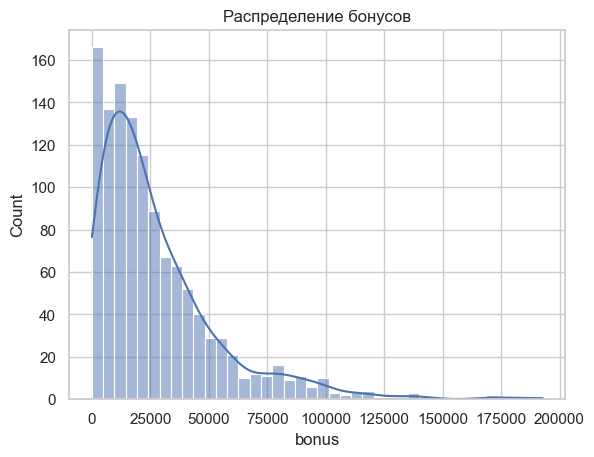

In [53]:
sns.histplot(data=df, x='bonus', bins=40, kde=True)
plt.title('Распределение бонусов')
print('skew bonus:', round(df['bonus'].skew(), 2))
print('skew log1p(bonus):', round(np.log1p(df['bonus']).skew(), 2));
# Ожидаемый результат: bonus skew ~2.06 (сильный скос вправо),
# после log1p ~ -1.14 — знак сменился на минус: логарифм ПЕРЕСТАРАЛСЯ, стало скошено влево

**Вывод:** Бонусы сильно скошены вправо (skew ~2.06). Логарифм уменьшил скос по модулю, но перестарался — асимметрия стала отрицательной (~−1.14), то есть распределение перекосило влево. Вывод: преобразование нужно подбирать и проверять по числу, а не применять вслепую.

### <font color='DarkOrange'>Задание 9 [3 балла]</font>

Посмотрите, как логарифм влияет на **связь** опыта и зарплаты. Постройте два точечных графика: `experience` vs `salary` и `experience` vs `log_salary`. На каком связь читается чётче и почему?

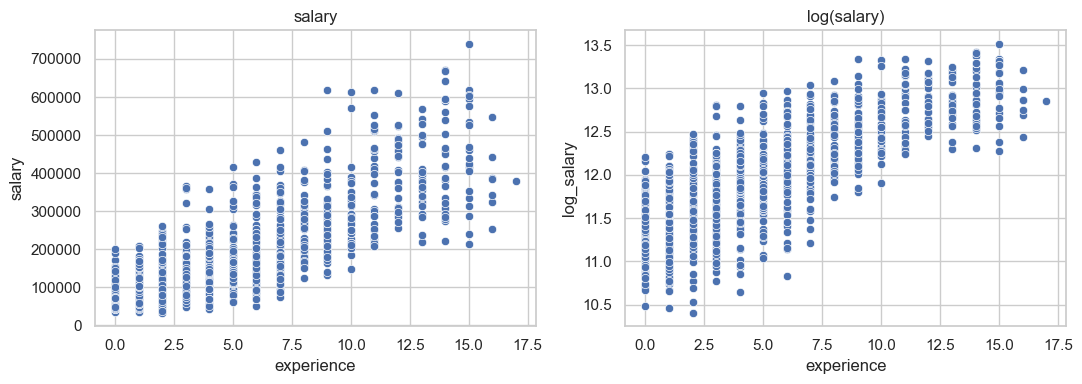

In [54]:
df['log_salary'] = np.log(df['salary'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=df, x='experience', y='salary', ax=axes[0]); axes[0].set_title('salary')
sns.scatterplot(data=df, x='experience', y='log_salary', ax=axes[1]); axes[1].set_title('log(salary)')
plt.tight_layout();
# Ожидаемый результат: слева облако раскрывается «воронкой» (разброс растёт с опытом),
# справа после логарифма — ровная восходящая полоса: связь видно чётче

**Вывод:** На сырой зарплате точки расходятся «воронкой» — с ростом опыта увеличивается и разброс. После логарифма разброс выравнивается, и восходящая связь опыта и зарплаты читается как ровная полоса. Логарифм не только нормализует форму, но и стабилизирует разброс.

### <font color='DarkOrange'>Задание 10 [3 балла]</font>

Итоговое исследование. Найдите отдел с самой **высокой** и самой **низкой** медианной зарплатой, постройте их распределения на одном графике (`kdeplot` с `hue`) и сравните форму и типичный уровень. Сделайте вывод 2–3 предложения.

ниже всех: Поддержка | выше всех: Инженерия
department
Поддержка    105979.0
HR           114432.0
Маркетинг    137864.0
Финансы      138747.0
Продажи      149713.0
Инженерия    166650.0
Name: salary, dtype: float64


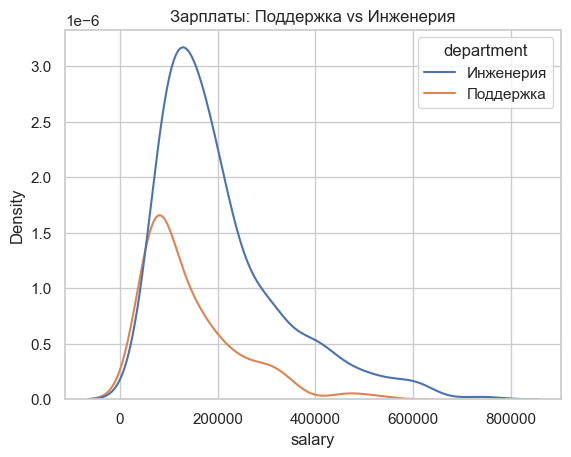

In [55]:
med = df.groupby('department')['salary'].median().sort_values()
low, high = med.index[0], med.index[-1]
print('ниже всех:', low, '| выше всех:', high)
print(med.round())

sub = df[df['department'].isin([low, high])]
sns.kdeplot(data=sub, x='salary', hue='department')
plt.title(f'Зарплаты: {low} vs {high}');
# Ожидаемый результат: ниже всех — Поддержка (~106k), выше всех — Инженерия (~167k);
# у Инженерии пик правее и хвост длиннее, обе скошены вправо

**Вывод:** Ниже всех платят в Поддержке (медиана ~106k), выше всех — в Инженерии (~167k). Обе кривые скошены вправо, но у Инженерии пик смещён правее и хвост длиннее — там и типичный уровень выше, и больше высокооплачиваемых. Отдел заметно влияет на зарплату.